In [35]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import xarray as xr
import numpy as np
import os
from glob import glob
from mpl_toolkits.basemap import Basemap
from numpy import meshgrid
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable
import cartopy.feature as cfeature
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter, LatitudeLocator
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, TwoSlopeNorm
import matplotlib.ticker as ticker
from matplotlib.cm import ScalarMappable
from matplotlib import colormaps
import pandas as pd
import math
from datetime import datetime
import datetime as dt
from ridgeplot import ridgeplot
import joypy
import seaborn as sns
from matplotlib import cm
import climpred
from xclim import sdba
from climpred.options import OPTIONS
import json
from sklearn.metrics import roc_curve, auc, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from matplotlib.lines import Line2D  # For custom legend entries
import warnings
from sklearn.exceptions import UndefinedMetricWarning
import matplotlib.gridspec as gridspec
import hydroeval as he
import re
from matplotlib.colors import Normalize
import matplotlib.colors as mcolors
import dill

from function import preprocessUtils as putils
from function import masks
from function import verifications
from function import funs as f
from function import conf
from function import loadbias
from function import quikplot as qp
from function import dataLoad
from function import conf


warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

global dim_order, region_name, test_year, leads_
dim_order = conf.dim_order

test_year = 2019
leads_ = [6,13,20,27]

dir = '/glade/work/klesinger/FD_RZSM_deep_learning'
assert test_year == 2019, 'This is only the script for when the testing years are 2018-2019. Test year must = 2019.'


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## For this script, we are going to plot the CRPSS based on climatology.

In [2]:
obs_source = 'GLEAM' #['GLEAM','ERA5']
week_lead=3
day_num = (week_lead*7)-1


In [3]:
def load_masks(region_name):
    region_name = 'CONUS' #['australia','china','CONUS']
    mask, mask_anom = masks.load_mask_vals(region_name)
    try:
        mask = mask.rename({'X':'longitude','Y':'latitude'})
    except ValueError:
        pass
    return mask,mask_anom

# Load the EXperiment CRPS and plot

In [6]:
def return_vals_by_lead(region_name,week_lead,obs_source,out_dict,ex1='EX29'):
    mask,mask_anom = load_masks(region_name)
    obs_dir = f'Data/climatology_crps/{region_name}'

    f=f'Data/climatology_crps/{region_name}/Wk{week_lead}_crps_{obs_source}.nc'

    obs_CRPS=xr.open_dataset(f)
    
    dict_dir = f'Data/CRPS_dict_values/{region_name}'
    with open(f'{dict_dir}/Wk_{week_lead}/CRPS_vals_{obs_source}.pkl','rb') as f:
        dict_val = dill.load(f)
        
    gefs_unet = dict_val[f'Wk{week_lead}_{ex1}_MEM_RZSM_CRPS']
    ecmwf_unet = dict_val[f'Wk{week_lead}_{ex1}_ECMWF_MEM_RZSM_CRPS']
    
    ecmwf = dict_val[f'Wk{week_lead}_ECMWF_MEM_baseline_RZSM_CRPS']
    gefs = dict_val[f'Wk{week_lead}_GEFS_MEM_baseline_RZSM_CRPS']

    out_dict[region_name]={}
    #now compute the CRPSS (1 - crps[forecast]/crps[climatology])
    crpss_unetG = 1 - (gefs_unet/obs_CRPS)
    crpss_unetG = crpss_unetG.median(dim='init')
    
    crpss_unetE = 1 - (ecmwf_unet/obs_CRPS)
    crpss_unetE = crpss_unetE.median(dim='init')
    
    #now compute the CRPSS (1 - crps[forecast]/crps[climatology])
    crpss_G = 1 - (gefs/obs_CRPS)
    crpss_G = crpss_G.median(dim='init')
    
    crpss_E = 1 - (ecmwf/obs_CRPS)
    crpss_E = crpss_E.median(dim='init')

    out_dict[region_name]={'DL-DM_G':crpss_unetG, 'DL-DM_E': crpss_unetE, 'GEFSv12':crpss_G, 'ECMWF':crpss_E}
    
    return out_dict

In [11]:
out_dict={}
for region_name in ['CONUS','china','australia']:
    out_dict = return_vals_by_lead(region_name,week_lead,obs_source,out_dict,ex1='EX29')

In [8]:

def plot_by_source(week_lead, obs_source,source):
    save_dir = f'Outputs/crpss_climatology/Wk{week_lead}'
    os.makedirs(save_dir,exist_ok=True)
    
    
    #Choose only a single experiment type
    dl_dm_g_dict = {}
    for region_name in ['CONUS','china','australia']:
        dl_dm_g_dict[region_name] = out_dict[region_name][source]
    
    # Calculate global vmin and vmax
    all_vals = [ds['crps'].values for ds in dl_dm_g_dict.values()]
    global_max = np.nanmax([np.nanmax(d) for d in all_vals])
    global_min = 0
    
    v = np.linspace(0, global_max, 10, endpoint=True)
    norm = Normalize(vmin=v[0], vmax=v[-1])
    cmap = 'YlOrRd'
    
    fig, axs = plt.subplots(nrows=1, ncols=3, subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(15, 5), dpi=150)
    axs = axs.flatten()
    
    for i, (region, ds) in enumerate(dl_dm_g_dict.items()):
        crps = xr.where(ds['crps']>0,ds['crps'],np.nan).values
        lon = ds['lon'].values
        lat = ds['lat'].values
    
        m = Basemap(projection='cyl',
                    llcrnrlat=lat[-1] - 1, urcrnrlat=lat[0] + 1,
                    llcrnrlon=lon[0] - 1, urcrnrlon=lon[-1] + 1,
                    resolution='l', ax=axs[i])
        
        x, y = np.meshgrid(lon, lat)
        im = axs[i].contourf(x, y, crps, levels=v, cmap=cmap, norm=norm, extend='both')
        axs[i].coastlines()
        axs[i].set_title(f"{region.upper()} - {source}")
    
        gl = axs[i].gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
        gl.top_labels = False
        gl.right_labels = False
        gl.left_labels = True
        gl.xformatter = LongitudeFormatter()
        gl.yformatter = LatitudeFormatter()
        gl.xlabel_style = {'size': 10}
        gl.ylabel_style = {'size': 10}
    
    # Colorbar
    cbar_ax = fig.add_axes([0.25, 0.15, 0.5, 0.05])
    cbar=fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
    cbar.set_label('CRPSS', fontsize=12)
    plt.tight_layout(rect=[0, 0.1, 1, 1])
    
    save_file = f'{save_dir}/CRPSS_greater_than_climatology_NO_BOOTSTRAP_{source}_{obs_source}.png'
    print(f'Saving image to {save_file}')
    plt.savefig(save_file, dpi=300)
    
    plt.show()

/glade/derecho/scratch/klesinger/tmp/ipykernel_112559/763279174.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])


Saving image to Outputs/crpss_climatology/Wk3/CRPSS_greater_than_climatology_NO_BOOTSTRAP_DL-DM_G_GLEAM.png


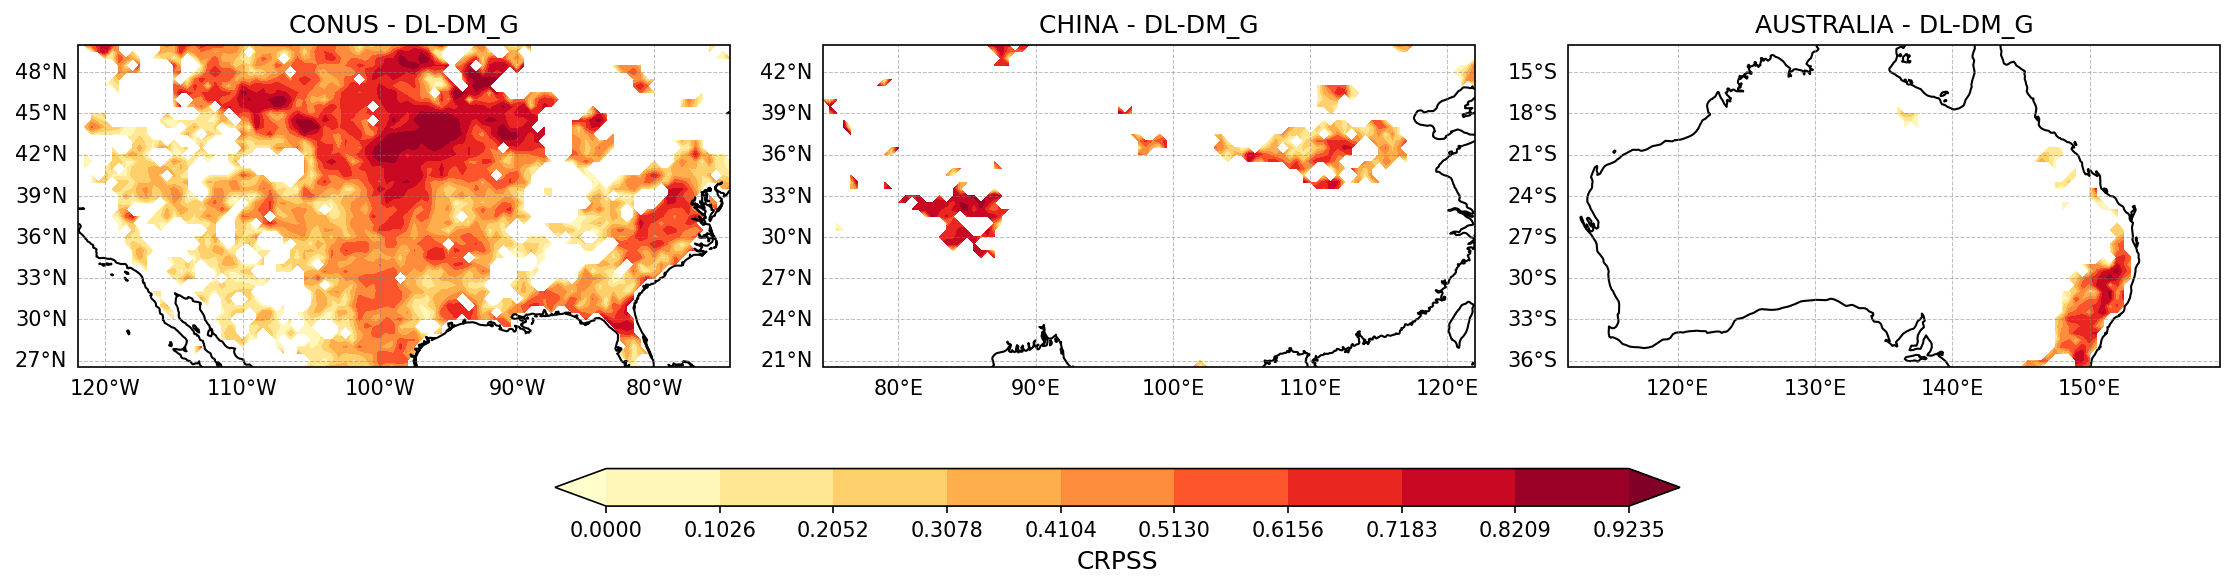

/glade/derecho/scratch/klesinger/tmp/ipykernel_112559/763279174.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])


Saving image to Outputs/crpss_climatology/Wk3/CRPSS_greater_than_climatology_NO_BOOTSTRAP_DL-DM_E_GLEAM.png


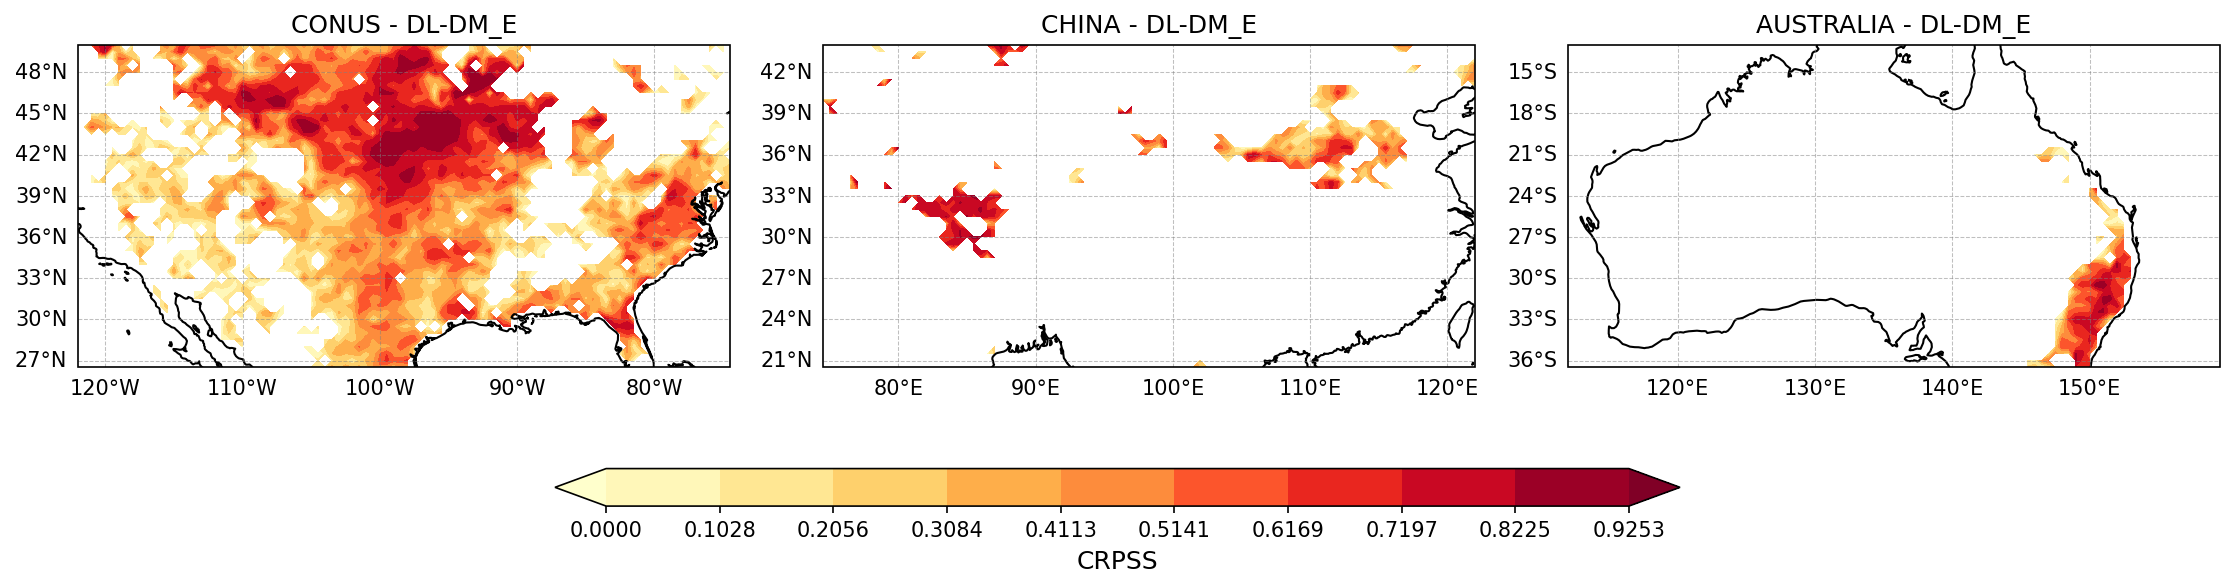

/glade/derecho/scratch/klesinger/tmp/ipykernel_112559/763279174.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])


Saving image to Outputs/crpss_climatology/Wk3/CRPSS_greater_than_climatology_NO_BOOTSTRAP_ECMWF_GLEAM.png


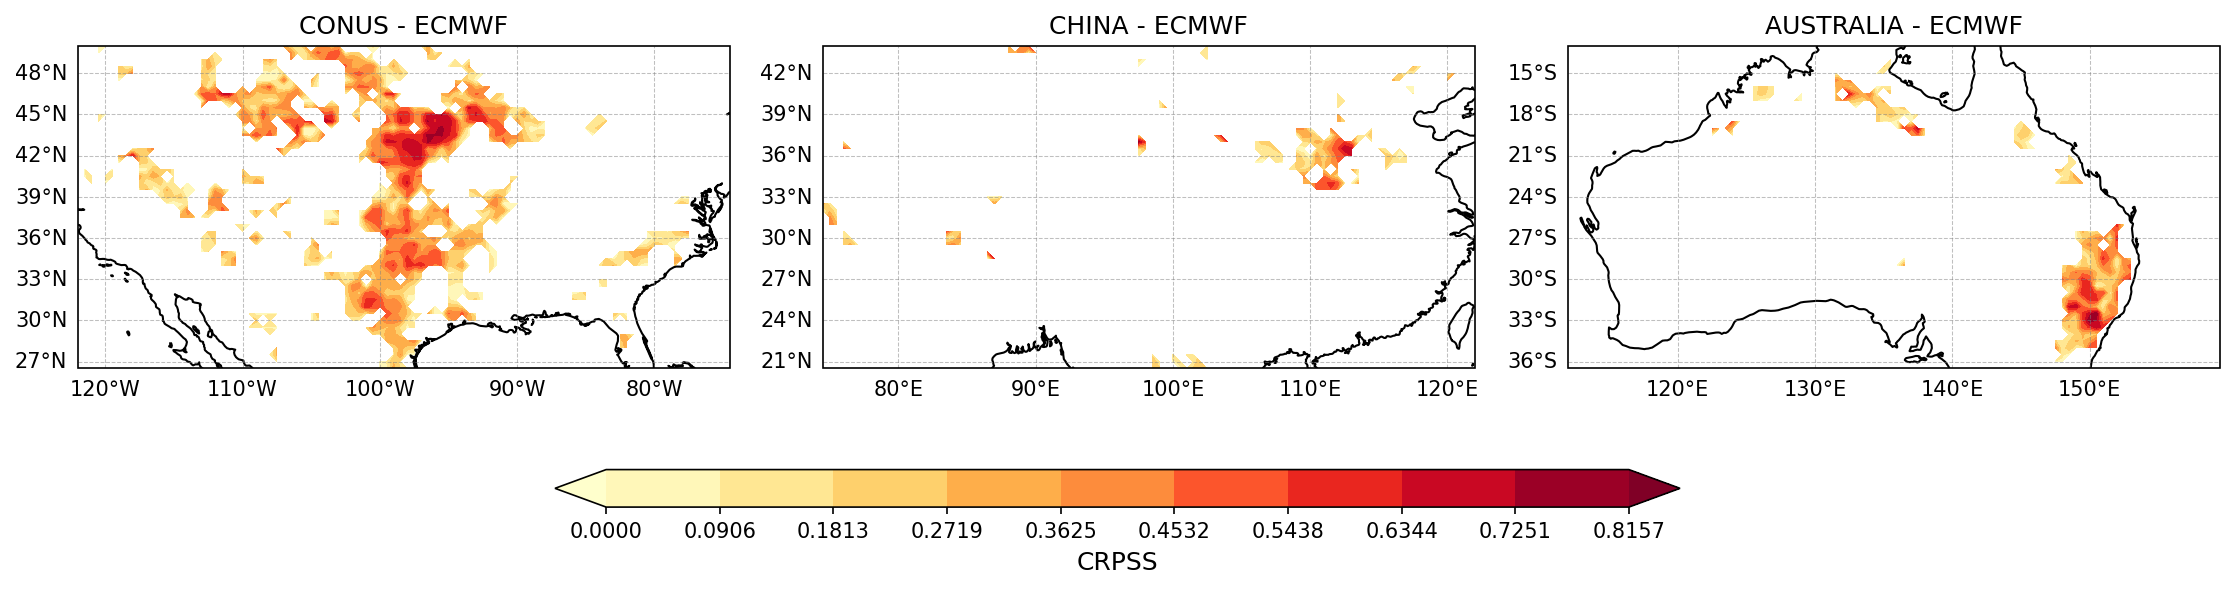

/glade/derecho/scratch/klesinger/tmp/ipykernel_112559/763279174.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])


Saving image to Outputs/crpss_climatology/Wk3/CRPSS_greater_than_climatology_NO_BOOTSTRAP_GEFSv12_GLEAM.png


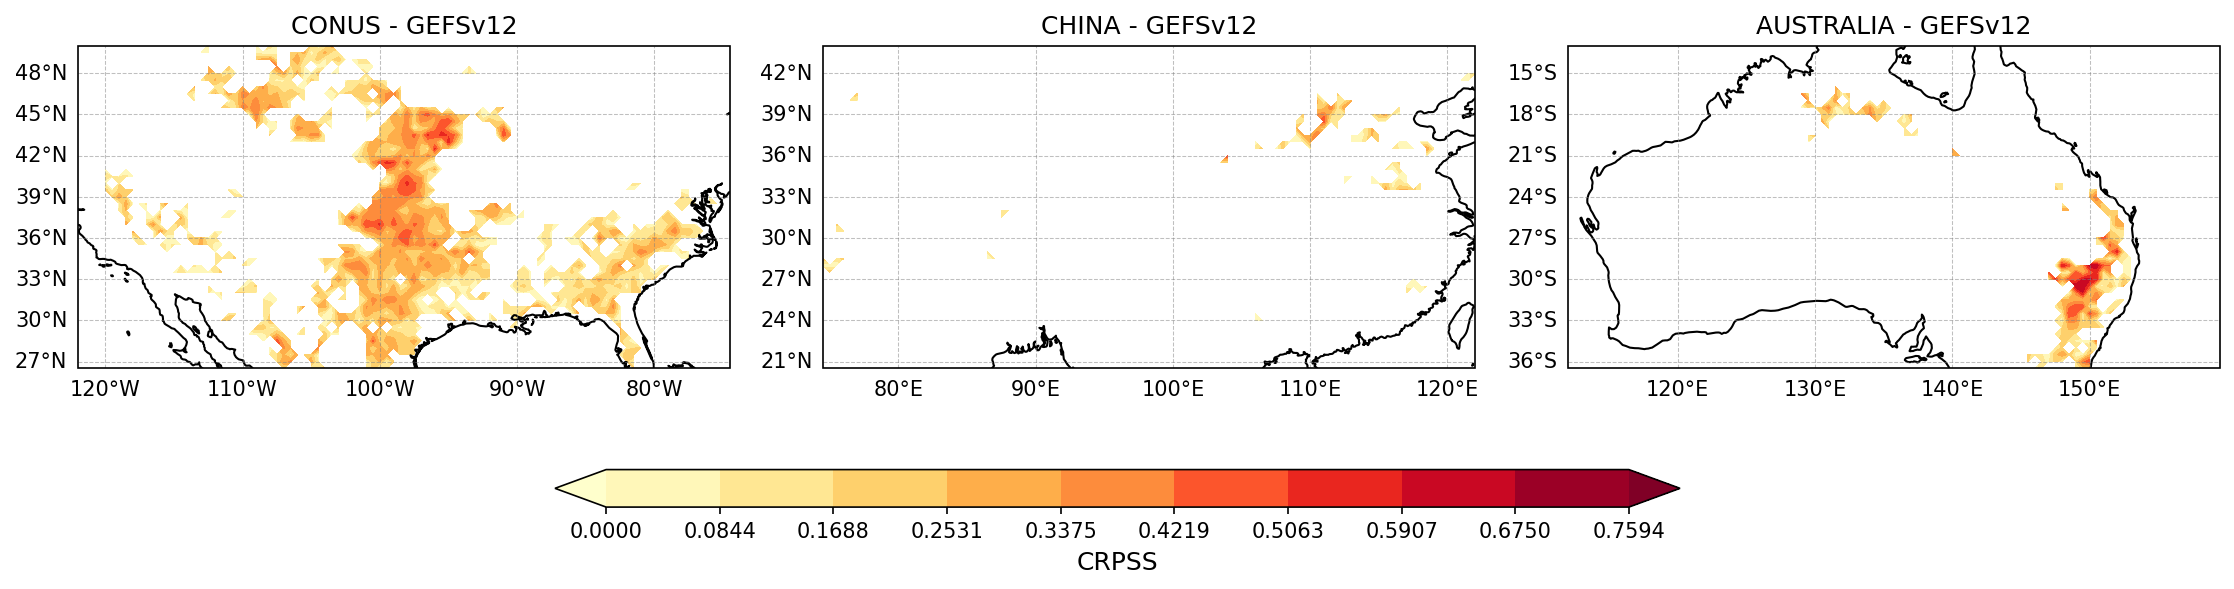

In [9]:
for source in ['DL-DM_G','DL-DM_E','ECMWF','GEFSv12']:
    plot_by_source(week_lead, obs_source,source)

In [100]:
def return_vals_by_lead_by_season(region_name,week_lead,obs_source,out_dict,ex1='EX29'):
    mask,mask_anom = load_masks(region_name)
    obs_dir = f'Data/climatology_crps/{region_name}'

    file=f'Data/climatology_crps/{region_name}/Wk{week_lead}_crps_{obs_source}.nc'

    obs_CRPS=xr.open_dataset(file)
    
    dict_dir = f'Data/CRPS_dict_values/{region_name}'
    with open(f'{dict_dir}/Wk_{week_lead}/CRPS_vals_{obs_source}.pkl','rb') as file:
        dict_val = dill.load(file)
        
    gefs_unet = dict_val[f'Wk{week_lead}_{ex1}_MEM_RZSM_CRPS']
    gefs_unet['init'] = xr.decode_cf(gefs_unet)['init']
    ecmwf_unet = dict_val[f'Wk{week_lead}_{ex1}_ECMWF_MEM_RZSM_CRPS']
    ecmwf_unet['init'] = xr.decode_cf(ecmwf_unet)['init']
    
    ecmwf = dict_val[f'Wk{week_lead}_ECMWF_MEM_baseline_RZSM_CRPS']
    ecmwf['init'] = xr.decode_cf(ecmwf)['init']
    gefs = dict_val[f'Wk{week_lead}_GEFS_MEM_baseline_RZSM_CRPS']
    gefs['init'] = xr.decode_cf(gefs)['init']

    out_dict[region_name]={}

    season_months = f.return_seasons()
    for season, months in season_months.items():
        #now compute the CRPSS (1 - crps[forecast]/crps[climatology])
        crpss_unetG = 1 - (gefs_unet.sel(init=gefs_unet['init'].dt.month.isin(months))/obs_CRPS.sel(init=obs_CRPS['init'].dt.month.isin(months)))
        crpss_unetG = crpss_unetG.median(dim='init')
        
        crpss_unetE = 1 - (ecmwf_unet.sel(init=ecmwf_unet['init'].dt.month.isin(months))/obs_CRPS.sel(init=obs_CRPS['init'].dt.month.isin(months)))
        crpss_unetE = crpss_unetE.median(dim='init')
        
        #now compute the CRPSS (1 - crps[forecast]/crps[climatology])
        crpss_G = 1 - (gefs.sel(init=gefs['init'].dt.month.isin(months))/obs_CRPS.sel(init=obs_CRPS['init'].dt.month.isin(months)))
        crpss_G = crpss_G.median(dim='init')
        
        crpss_E = 1 - (ecmwf.sel(init=ecmwf['init'].dt.month.isin(months))/obs_CRPS.sel(init=obs_CRPS['init'].dt.month.isin(months)))
        crpss_E = crpss_E.median(dim='init')
    
        out_dict[region_name][season]={'DL-DM_G':crpss_unetG, 'DL-DM_E': crpss_unetE, 'GEFSv12':crpss_G, 'ECMWF':crpss_E}
        
    return out_dict

In [101]:
out_dict_season={}
for region_name in ['CONUS','china','australia']:
    out_dict_season = return_vals_by_lead_by_season(region_name,week_lead,obs_source,out_dict_season,ex1='EX29')

In [144]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter
from matplotlib.colors import Normalize
from mpl_toolkits.basemap import Basemap

def plot_crpss_by_region_season_model(out_dict_season, week_lead, obs_source):
    save_dir = f'Outputs/crpss_climatology_season/Wk{week_lead}'
    os.makedirs(save_dir, exist_ok=True)

    model_order = ['DL-DM_G', 'DL-DM_E', 'GEFSv12', 'ECMWF']
    season_names = ['DJF', 'MAM', 'JJA', 'SON']
    season_months = {
        'DJF': [12, 1, 2],
        'MAM': [3, 4, 5],
        'JJA': [6, 7, 8],
        'SON': [9, 10, 11]
    }

    for region_name in out_dict_season.keys():
        fig, axs = plt.subplots(nrows=4, ncols=4, figsize=(20, 12), subplot_kw={'projection': ccrs.PlateCarree()}, dpi=150)
        axs = axs.reshape(4, 4)

        # Collect values for color scale normalization
        all_vals = []


        for j, season in enumerate(season_names):
            ds = out_dict_season[region_name][season]
            for i, model in enumerate(model_order):
                months = season_months[season]
                ds_mod = ds[model]

                # Handle seasonal selection
                crps = ds_mod['crps'].where(ds_mod['crps'] > 0, np.nan)
                all_vals.append(crps)

                lon = ds_mod['lon'].values
                lat = ds_mod['lat'].values
                ax = axs[i, j]

                m = Basemap(projection='cyl',
                            llcrnrlat=lat[-1] - 1, urcrnrlat=lat[0] + 1,
                            llcrnrlon=lon[0] - 1, urcrnrlon=lon[-1] + 1,
                            resolution='l', ax=ax)

                x, y = np.meshgrid(lon, lat)
                im = ax.contourf(x, y, crps, levels=10, cmap='YlOrRd',
                                 norm=Normalize(vmin=0, vmax=np.nanmax(all_vals)))
                ax.coastlines()
                ax.set_title(f"{model} - {season}", fontsize=10)

                gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
                gl.top_labels = False
                gl.right_labels = False
                gl.left_labels = i == 0
                gl.bottom_labels = j == 3
                gl.xformatter = LongitudeFormatter()
                gl.yformatter = LatitudeFormatter()

        cbar_ax = fig.add_axes([0.3, 0.08, 0.4, 0.02])
        cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
        cbar.set_label('CRPSS', fontsize=12)

        plt.tight_layout(rect=[0, 0.1, 1, 1])
        save_file = f'{save_dir}/CRPSS_seasonal_{region_name}_{obs_source}.png'
        print(f"Saving {save_file}")
        plt.savefig(save_file, dpi=300)
        plt.close()


In [145]:
plot_crpss_by_region_season_model(out_dict_season, week_lead=3, obs_source=obs_source)

/glade/derecho/scratch/klesinger/tmp/ipykernel_112559/855740536.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])


Saving Outputs/crpss_climatology_season/Wk3/CRPSS_seasonal_CONUS_GLEAM.png


/glade/derecho/scratch/klesinger/tmp/ipykernel_112559/855740536.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])


Saving Outputs/crpss_climatology_season/Wk3/CRPSS_seasonal_china_GLEAM.png


/glade/derecho/scratch/klesinger/tmp/ipykernel_112559/855740536.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])


Saving Outputs/crpss_climatology_season/Wk3/CRPSS_seasonal_australia_GLEAM.png
